<a href="https://colab.research.google.com/github/gkchandu/retail-sales-analytics-project/blob/main/01_Retail_Analytics_Data_Cleaning_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

df = pd.read_csv('/content/drive/MyDrive/Retail_Sales_Analytics_Project/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Check Missing Values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
# Check Duplicate Values
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates found: 0


## Data Quality Check

Before analysis, the dataset was checked for missing values and duplicate rows using `df.isnull().sum()` and `df.duplicated().sum()`.

- **Missing values:** None found across any column, including Postal Code.
- **Duplicate rows:** None found.
- **Conclusion:** The dataset was already clean and well-maintained, requiring no imputation or row removal. This step confirms data integrity before proceeding to outlier analysis and visualization.

Outlier detection, however, did reveal meaningful patterns — see Profit distribution analysis below.




In [12]:
# Fixing Data Types
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

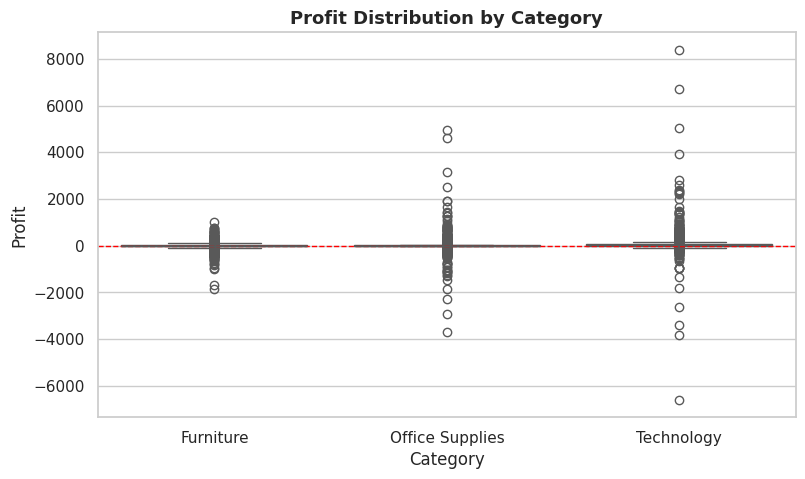

In [15]:
# Outliers Boxplot
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Category', y='Profit', hue='Category', palette='Set2', legend=False)
plt.title('Profit Distribution by Category', fontsize=13, fontweight='bold')
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # marks the "break-even" line
plt.show()

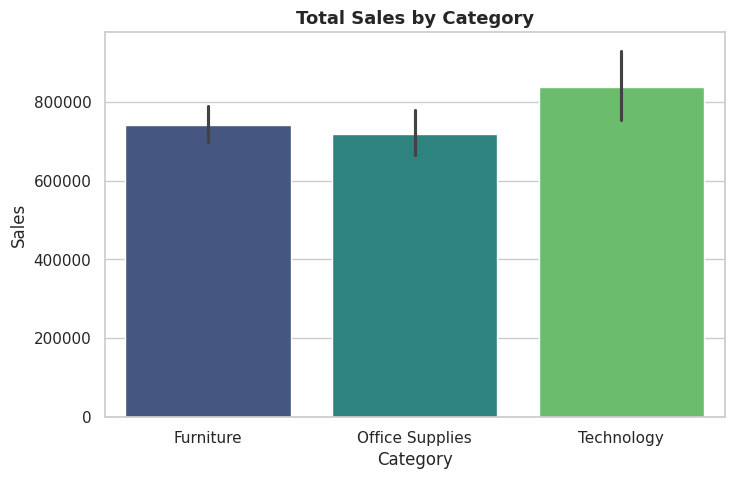

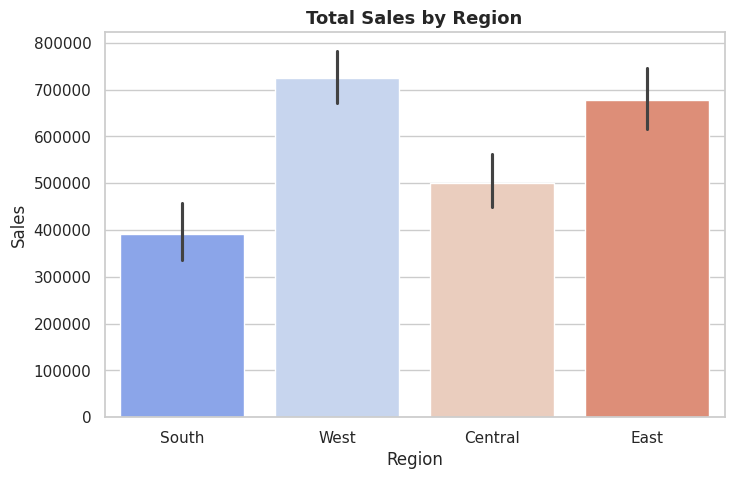

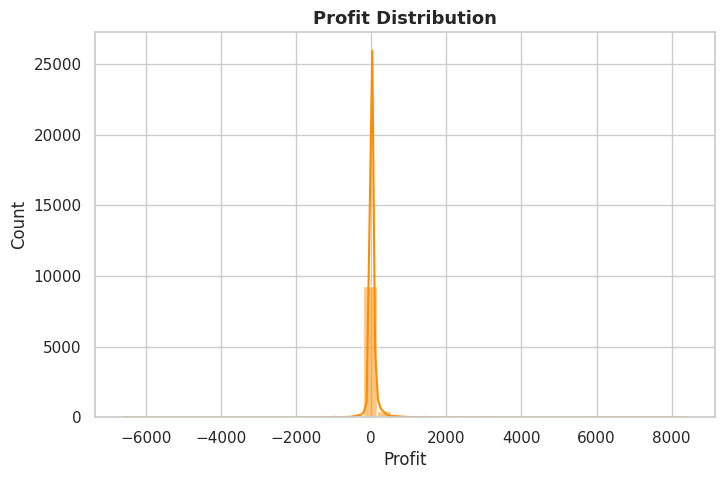

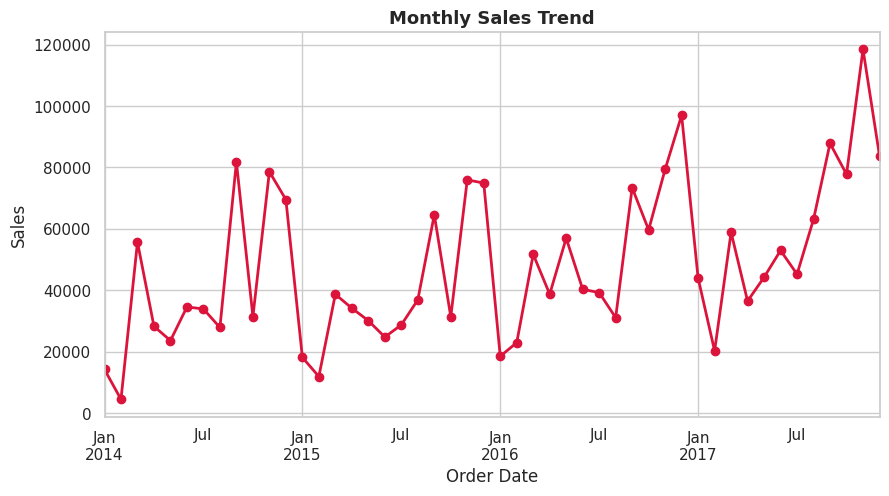

In [17]:
# Charts

# 1. Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Sales', estimator=sum, hue='Category', palette='viridis', legend=False)
plt.title('Total Sales by Category', fontsize=13, fontweight='bold')
plt.show()

# 2. Sales by Region
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Region', y='Sales', estimator=sum, hue='Region', palette='coolwarm', legend=False)
plt.title('Total Sales by Region', fontsize=13, fontweight='bold')
plt.show()

# 3. Profit distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Profit', bins=40, color='darkorange', kde=True)
plt.title('Profit Distribution', fontsize=13, fontweight='bold')
plt.show()

# 4. Monthly Sales trend over time
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot(color='crimson', linewidth=2, marker='o')
plt.title('Monthly Sales Trend', fontsize=13, fontweight='bold')
plt.ylabel('Sales')
plt.show()

In [18]:
# Extracted year from the monthly period, to find the max sales value per year (From Chart 4. Sales trend over time)
yearly_peaks = monthly_sales.groupby(monthly_sales.index.year).max()
print(yearly_peaks)

Order Date
2014     81777.3508
2015     75972.5635
2016     96999.0430
2017    118447.8250
Name: Sales, dtype: float64


### Chart 5: Discount vs Profit
Following up on the negative profit values seen in Chart 3, this scatter plot investigates whether higher discounts are driving those losses.

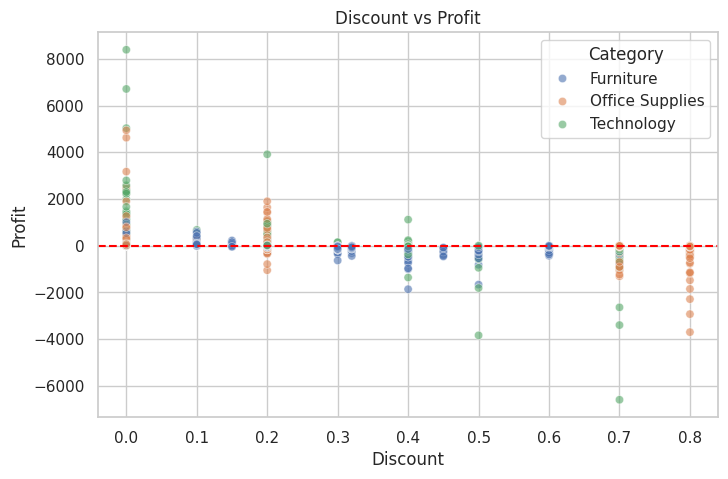

In [19]:
# Discount vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.show()

## Key Insights

- **No missing values or duplicates** were found — the dataset was already clean and well-maintained (see Data Quality Check above).

- **Technology leads in total sales**, crossing 800,000 — noticeably ahead of Furniture and Office Supplies, which are fairly close to each other.

- **Sales vary significantly by region**: the West region leads with over 700,000 in sales, while the South region trails behind at under 400,000 — a gap worth exploring further (possibly fewer stores, lower demand, or logistics factors in the South).

- **Profit is centered around 0**, with a large concentration of orders (over 25,000 in the peak bin) clustered right at break-even. The distribution leans slightly toward positive profit overall, but the presence of a spread on both sides indicates some orders result in losses.

- **Sales show strong seasonality rather than a steady trend** — the monthly sales trend is spiky, not flat, with recurring peaks toward the end of each year. Year-over-year peak values were: 2014 (81,777), 2015 (75,972 — a slight dip), 2016 (96,999), and 2017 (118,448 — the highest). This shows overall growth from 2015 onward, with 2017 marking a clear high point. The lowest point across the full period was February 2014.

- **Discount is a major driver of losses**: at 0% discount, profit is almost entirely positive (up to 8,000+), but profit drops sharply as discount increases — by 70-80% discount, nearly every order is a loss, some as severe as -6,000. **Technology is the most volatile category**, showing both the highest profit spikes at low discounts and the steepest losses at high discounts.

- **Overall pattern**: Sales are strongest in Technology and the West region, with clear seasonal peaks each year-end and overall growth from 2015 to 2017. Losses are strongly tied to heavy discounting, especially in Technology — a clear, actionable finding for future business recommendations.